## Observability in Langgraph

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage , HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [ ]:
model = ChatOpenAI(model = "gpt-5.4-mini-2026-03-17" , temperature = 0)
# model = ChatOpenAI(
#     model="openai/gpt-5.4-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0,
# )

In [5]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [6]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = model.invoke(messages)

    # response store state
    return {'messages': [response]}

In [7]:
# Checkpointer
checkpointer = InMemorySaver()

graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

chatbot = graph.compile(checkpointer=checkpointer)

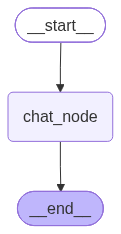

In [8]:
chatbot

In [9]:
initial_state = {
    'messages': [HumanMessage(content='Write a 1000 words essay on Freedom Fighters of India')]
}

In [10]:
config = {'configurable': {'thread_id': 'thread-1'}}

In [11]:
final_state = chatbot.invoke(initial_state , config=config)


In [12]:
final_state

{'messages': [HumanMessage(content='Write a 1000 words essay on Freedom Fighters of India', additional_kwargs={}, response_metadata={}, id='bd7ca2f7-196c-4b71-a31b-c68b993e4802'),
  AIMessage(content='India’s struggle for independence was one of the most remarkable freedom movements in modern history. It was not achieved by a single leader or a single event, but by the courage, sacrifice, and determination of countless men and women who devoted their lives to the cause of freedom. These freedom fighters came from different regions, religions, castes, and backgrounds, yet they were united by one dream: to see India free from British rule. Their efforts inspired the masses, awakened national consciousness, and paved the way for the independence of India on 15 August 1947.\n\nThe Indian freedom struggle began in the late 18th century and gained momentum in the 19th and 20th centuries. At first, resistance against British rule took the form of local revolts and uprisings. Later, it evolved

In [13]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of China')]
}

In [14]:
final_state = chatbot.invoke(initial_state , config=config)

In [15]:
final_state

{'messages': [HumanMessage(content='Write a 1000 words essay on Freedom Fighters of India', additional_kwargs={}, response_metadata={}, id='bd7ca2f7-196c-4b71-a31b-c68b993e4802'),
  AIMessage(content='India’s struggle for independence was one of the most remarkable freedom movements in modern history. It was not achieved by a single leader or a single event, but by the courage, sacrifice, and determination of countless men and women who devoted their lives to the cause of freedom. These freedom fighters came from different regions, religions, castes, and backgrounds, yet they were united by one dream: to see India free from British rule. Their efforts inspired the masses, awakened national consciousness, and paved the way for the independence of India on 15 August 1947.\n\nThe Indian freedom struggle began in the late 18th century and gained momentum in the 19th and 20th centuries. At first, resistance against British rule took the form of local revolts and uprisings. Later, it evolved

## to enable threads tracing

In [25]:
config = {'configurable': {'thread_id': 'thread-2'},
"metadata": {"thread_id": "thread-2"},
"run_name": "chat_turn"}

In [26]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of China')]
}

In [27]:
final_state = chatbot.invoke(initial_state , config=config)

In [28]:
final_state

{'messages': [HumanMessage(content='What is the capital of China', additional_kwargs={}, response_metadata={}, id='b1ac426a-f095-4d35-ac56-cc82f8efc553'),
  AIMessage(content='The capital of China is **Beijing**.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 12, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EE4DWPd9QgAGwESd8wvKZWrEQKpAr', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a012c8-4390-70a2-bf1c-a392f2dab994-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 13, 'total_tokens': 25, 'input_token_details': {'audi

In [29]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of India')]
}

In [30]:
final_state = chatbot.invoke(initial_state , config=config)

In [31]:
final_state

{'messages': [HumanMessage(content='What is the capital of China', additional_kwargs={}, response_metadata={}, id='b1ac426a-f095-4d35-ac56-cc82f8efc553'),
  AIMessage(content='The capital of China is **Beijing**.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 12, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EE4DWPd9QgAGwESd8wvKZWrEQKpAr', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a012c8-4390-70a2-bf1c-a392f2dab994-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 13, 'total_tokens': 25, 'input_token_details': {'audi